# 19_参数估计方法-贝叶斯估计

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节，咱们来聊聊参数估计方法中的一种非常常用的一个方式：贝叶斯估计\~

### 先说参数估计是啥？

我们经常遇到这样的问题：

> 有一些数据，但不知道数据背后的分布参数是多少，想要估计出这个参数。

比如：

- 假设你在研究一枚硬币，你不知道它正面朝上的概率 $\theta$（比如是 0.5 还是 0.7？）。
- 你抛了 10 次硬币，看到了 7 次正面、3 次反面。
- 现在你想估计这枚硬币的 $\theta$ 值。

这就是**参数估计问题**。

### 贝叶斯估计 和 传统方法有什么不同？

传统的方法（比如最大似然估计 MLE）是这样做的：

> 我不相信任何先验知识，全靠眼前的数据，说看到 7 次正面，那我就估计概率是 7/10 = 0.7。

而贝叶斯估计是这么想的：

> 我原本对这枚硬币有一些**先验认知**（比如我觉得它应该接近公平，即 0.5），  
> 在看到数据（7次正面）之后，我就把这个认知**更新一下**，得出一个新的判断。

所以贝叶斯估计**结合了主观判断（先验）和实际数据（似然）**，是一种更稳健、更理性的估计方法。

## 贝叶斯估计的基本思路

核心思想一句话：

> 用**贝叶斯公式**，在已有先验的基础上，根据数据更新你对参数的认知。

公式：


$$
P(\theta | X) = \frac{P(X | \theta) \cdot P(\theta)}{P(X)}
$$


- $\theta$：未知参数（比如硬币正面概率）
- $X$：观测到的数据（比如抛了 10 次结果）
- $P(\theta)$：先验分布（你原来对 $\theta$ 的看法）
- $P(X | \theta)$：似然函数（数据在给定 $\theta$ 下的可能性）
- $P(\theta | X)$：后验分布（更新后的 $\theta$ 的分布）

## 举个简单例子：硬币抛掷

已知你抛了一枚硬币 10 次，出现 7 次正面。请估计这枚硬币正面朝上的概率 $\theta$。

### 贝叶斯估计步骤

**1）先验分布** $P(\theta)$：

假设我们对这枚硬币的先验看法是：它大概率是公平的，但也可能稍有偏差。

我们可以用**Beta分布**来描述这种不确定性：


$$
P(\theta) = \text{Beta}(\alpha, \beta)
$$


比如选 $\alpha = 2, \beta = 2$，这对应一个中心在 0.5 的分布（偏好公平硬币）。

**2）似然函数** $P(X|\theta)$：

你看到的数据是：7次正面，3次反面。

这是一个**二项分布**：


$$
P(X | \theta) = \binom{10}{7} \theta^7 (1 - \theta)^3
$$


**3）后验分布** $P(\theta | X)$：

现在我们用贝叶斯公式：


$$
P(\theta | X) \propto P(X | \theta) \cdot P(\theta)
$$


即：


$$
P(\theta | X) \propto \theta^7 (1 - \theta)^3 \cdot \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}= \theta^{7 + \alpha - 1}(1 - \theta)^{3 + \beta - 1}
$$


代入 $\alpha = 2, \beta = 2$ 得到：


$$
P(\theta | X) \propto \theta^{8}(1 - \theta)^{4}
$$


这还是一个**Beta分布**：


$$
P(\theta | X) = \text{Beta}(9, 5)
$$


**4）估计值**：

我们可以用后验分布的**期望**作为对 $\theta$ 的估计：


$$
\mathbb{E}[\theta] = \frac{\alpha' }{ \alpha' + \beta' } = \frac{9}{9 + 5} = \frac{9}{14} \approx 0.643
$$


这就是贝叶斯估计给出的结果。

相比最大似然估计（MLE = 7/10 = 0.7），它**略微偏向先验 0.5**，更加稳健。

## 数学原理

### 1）贝叶斯公式


$$
P(\theta | X) = \frac{P(X | \theta) \cdot P(\theta)}{P(X)}
$$


其中：

- $P(X) = \int P(X | \theta) P(\theta) d\theta$ 是规范化常数，确保后验分布总和为 1。

### 2）通用步骤：

假设：

- 数据： $X = \{x_1, x_2, ..., x_n\}$
- 参数： $\theta$，未知
- 先验分布： $P(\theta)$
- 数据的似然函数： $P(X|\theta) = \prod_{i=1}^n P(x_i|\theta)$

那么：

#### 后验分布：


$$
P(\theta|X) \propto P(X|\theta) \cdot P(\theta)
$$


#### 贝叶斯估计的常见估计值：

- **后验均值**：$\hat{\theta}_{\text{Bayes}} = \mathbb{E}[\theta | X] = \int \theta \cdot P(\theta|X) \, d\theta$
- **后验众数**：$\hat{\theta}_{\text{MAP}} = \arg \max_\theta P(\theta|X)$

## 贝叶斯估计算法流程

以 Beta-Binomial 为例：

**步骤：**

1. **设定先验分布**：

   - 根据经验或先验知识设定 $P(\theta)$，常用 Beta 分布。
   - Beta($\alpha, \beta$)。
2. **收集观测数据**：

   - 数据 $X = \{x_1, ..., x_n\}$，统计出成功次数 $k$，失败次数 $n-k$。
3. **写出似然函数**：


$$
P(X|\theta) = \theta^k (1 - \theta)^{n-k}
$$


1. **计算后验分布（乘法）**：


$$
P(\theta|X) \propto \theta^{k + \alpha - 1} (1 - \theta)^{n-k + \beta - 1}
$$


1. 所以后验还是一个 Beta 分布：


$$
P(\theta|X) = \text{Beta}(k + \alpha, n - k + \beta)
$$


1. **输出估计值**（任选其一）：$\mathbb{E}[\theta | X] = \frac{k + \alpha}{n + \alpha + \beta}$；$\frac{k + \alpha - 1}{n + \alpha + \beta - 2} \quad \text{（若参数 > 1）}$

   - **后验期望**：

   - **MAP（众数）**：

## 完整案例

一个市场分析师，负责预测**某电商平台商品的退货率**。

收集了一些历史订单数据：

- 每个商品的总销售数
- 实际发生的退货次数

想要为每个商品建立一个**退货概率的估计模型**。

但问题是：

> 某些商品只卖了几件，这种样本很小的情况下，直接用退货次数 / 销售数得出的概率会非常不稳定（波动大，偏差高）。

因此，我们采用 **贝叶斯估计方法**，引入合理的先验分布，对参数（退货概率）进行更稳定的估计。

### 数据集

模拟一个数据集，有 500 个商品，每个商品有不同的销量和退货数量。

采用如下模型结构：

- 每个商品 $i$ 的退货次数 $r_i$，满足：


$$
r_i \sim \text{Binomial}(n_i, \theta_i)
$$


- 其中 $n_i$ 是该商品的总销售量，$\theta_i$ 是该商品的真实退货率。
- 但 $\theta_i$ 是未知参数，我们用**贝叶斯方法来估计它**：


$$
\theta_i \sim \text{Beta}(\alpha, \beta)
$$


我们将使用先验 $\text{Beta}(2, 5)$ 表示「退货率总体偏低，大多数小于 0.5」的经验认知。

### 代码实现

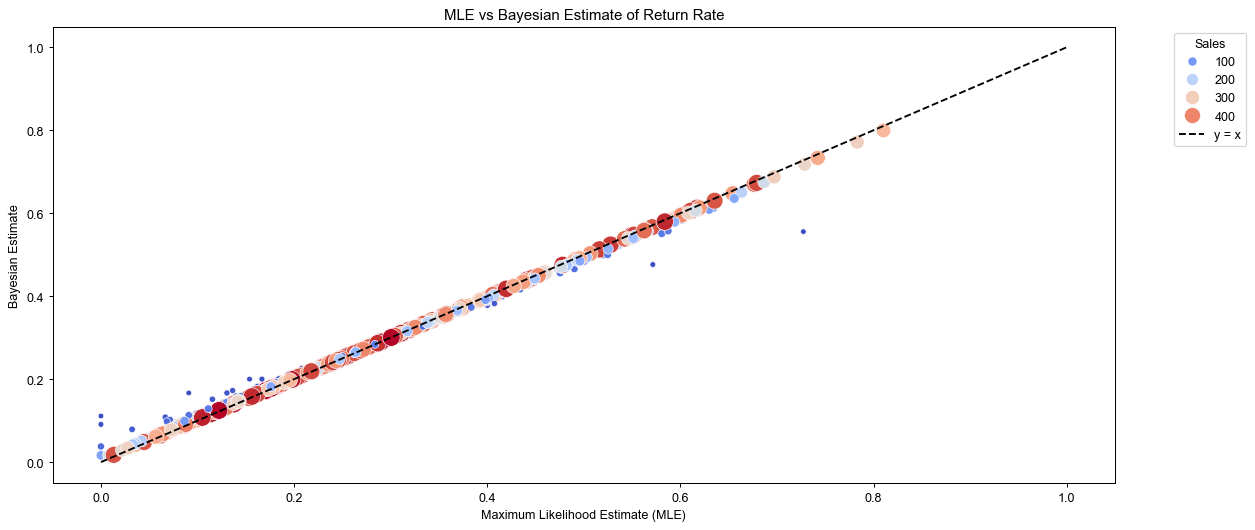

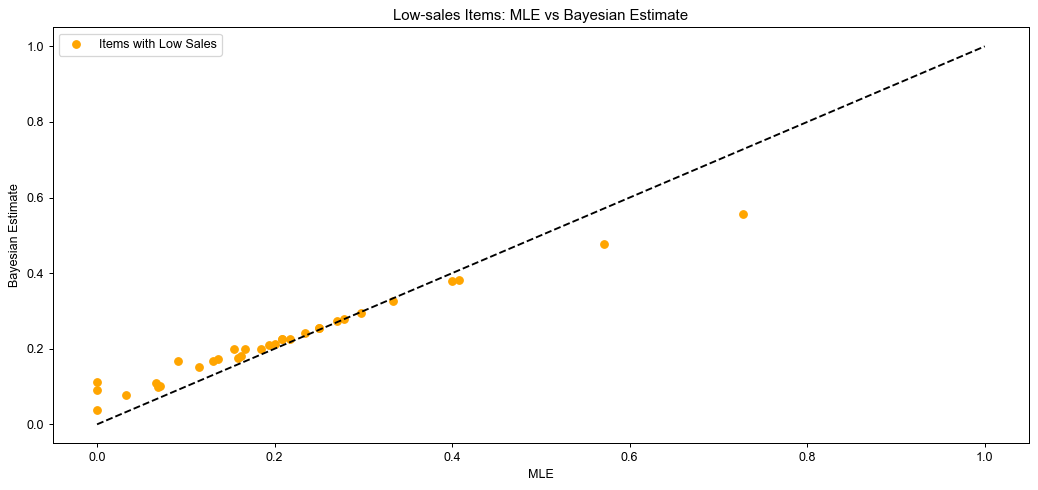

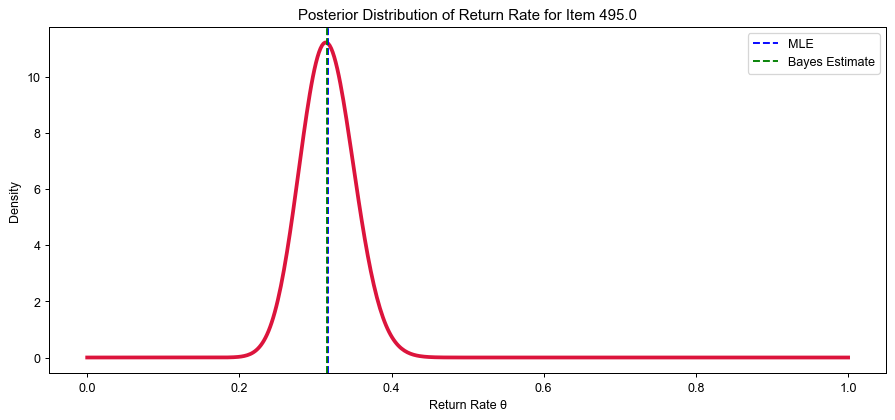

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta, binom

np.random.seed(42)

# 1. 商品数量
n_items = 500

# 每个商品的销售数量（10 ~ 500 之间）
sales = np.random.randint(10, 500, size=n_items)

# 每个商品的真实退货率（从 beta 分布生成）
true_return_rates = np.random.beta(2, 5, size=n_items)

# 实际退货数量（从 binomial 分布生成）
returns = np.random.binomial(sales, true_return_rates)

# 构建 DataFrame
df = pd.DataFrame({
    "item_id": np.arange(n_items),
    "sales": sales,
    "returns": returns,
    "true_return_rate": true_return_rates
})

# 计算频率估计（最大似然估计 MLE）
df["mle_return_rate"] = df["returns"] / df["sales"]

# 2. 贝叶斯估计部分
# 设置 beta 分布的先验参数
alpha_prior = 2
beta_prior = 5

# 后验参数（每个商品）
df["posterior_alpha"] = alpha_prior + df["returns"]
df["posterior_beta"] = beta_prior + (df["sales"] - df["returns"])

# 后验期望作为贝叶斯估计值
df["bayes_estimate"] = df["posterior_alpha"] / (df["posterior_alpha"] + df["posterior_beta"])

# 3. 可视化分析

# 3.1 比较 MLE 与 贝叶斯估计（带颜色区分销售量）
plt.figure(figsize=(14, 6))
sns.scatterplot(x="mle_return_rate", y="bayes_estimate", size="sales", hue="sales", data=df, palette="coolwarm", sizes=(20, 200))
plt.plot([0, 1], [0, 1], 'k--', label="y = x")
plt.title("MLE vs Bayesian Estimate of Return Rate")
plt.xlabel("Maximum Likelihood Estimate (MLE)")
plt.ylabel("Bayesian Estimate")
plt.legend(title="Sales", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3.2 销售量小的商品中，MLE 和贝叶斯估计偏差最大
small_sample = df[df["sales"] < 50]
plt.figure(figsize=(14, 6))
plt.scatter(small_sample["mle_return_rate"], small_sample["bayes_estimate"], color='orange', label='Items with Low Sales')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Low-sales Items: MLE vs Bayesian Estimate")
plt.xlabel("MLE")
plt.ylabel("Bayesian Estimate")
plt.legend()
plt.show()

# 3.3 后验分布示意图（选一个商品）
idx = df.sample(1).index[0]
item = df.loc[idx]

x = np.linspace(0, 1, 500)
posterior = beta.pdf(x, item["posterior_alpha"], item["posterior_beta"])
plt.figure(figsize=(12, 5))
plt.plot(x, posterior, color='crimson', lw=3)
plt.title(f"Posterior Distribution of Return Rate for Item {item['item_id']}")
plt.axvline(item["mle_return_rate"], color='blue', ls='--', label="MLE")
plt.axvline(item["bayes_estimate"], color='green', ls='--', label="Bayes Estimate")
plt.legend()
plt.xlabel("Return Rate θ")
plt.ylabel("Density")
plt.show()

#### 第一步：数据模拟

- 使用 Beta(2, 5) 分布来模拟商品的真实退货率（整体偏低）。
- 使用 Binomial 分布生成退货次数数据，反映每个商品的“观察数据”。
- 计算频率估计（退货次数 / 总销量）作为 MLE。

#### 第二步：贝叶斯估计

我们设定 Beta(2, 5) 的先验，进行如下更新：

- 后验分布是 Beta 分布：


$$
\text{Beta}(\alpha + r, \beta + n - r)
$$


- 使用后验分布的期望作为参数估计值：


$$
\mathbb{E}[\theta] = \frac{\alpha + r}{\alpha + \beta + n}
$$


#### 第三步：可视化分析

**1）MLE vs Bayesian估计图**：

- 横轴是频率估计，纵轴是贝叶斯估计。
- 颜色和点大小代表销售数量，发现低销量商品偏离对角线很大（即 MLE 很不稳定），而贝叶斯估计更稳定。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

**2）只看销售量小的商品**：

- MLE 会出现非常高或非常低的极端估计（因为样本小，易受偶然影响）。
- 贝叶斯估计有缓冲机制，不容易极端，较稳定。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**3）后验分布图示**：

- 展示某个商品的后验分布曲线。
- 清晰展示先验如何和数据结合，最后得出一个更合理的估计结果。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

### 贝叶斯估计优缺点分析

**优点**：

1. **更稳健，避免极端估计**：对于销量很小的商品，MLE 容易给出极高或极低的退货率估计；贝叶斯方法通过引入先验，能让估计更平滑。
2. **支持少量数据时推断**：对于数据稀少的新商品，贝叶斯估计能利用先验提供合理初始估计（零样本也可以推断）。
3. **生成完整的后验分布**：相比只得到一个点估计（如 MLE），贝叶斯估计可以输出整个参数的不确定性分布，用于后续决策（比如置信区间、风险分析等）。
4. **有先验时更有效率**：如果你确实有历史经验或行业背景知识，先验知识能显著提高估计质量。

**缺点**：

1. **需要先验分布**：选择先验具有一定主观性；如果先验选得不合适，可能造成偏差。
2. **计算复杂度高**：对于更复杂的问题（非共轭分布、模型结构复杂等），后验分布无法解析表达，必须使用数值方法（如 MCMC），计算代价高。
3. **不适合无偏估计**：贝叶斯估计往往带有「偏差」，特别是样本量很大时，反而可能不如 MLE 准确。

### 哪些情况适合使用贝叶斯估计？

1. **小样本场景**：如新商品、初期阶段数据量少，贝叶斯估计提供稳健估计。
2. **先验知识丰富**：例如有历史数据、行业经验可转化为先验分布。
3. **希望建模不确定性**：需要得到概率分布而非单点估计，如用于后续风险决策。
4. **高成本预测错误时**：当模型失误代价高（如医疗、金融领域），贝叶斯估计因更稳健而更安全。
5. **数据有噪声/极端值**：传统方法易受极端值影响，贝叶斯估计内在有「正则化」效果，抑制极端影响。

## 总结

在上面的案例中，展示了贝叶斯估计在真实问题中非常强大能力：

- 通过 Beta-Binomial 模型对商品退货率进行建模；
- 结合先验与观测，得到更合理、更稳健的估计；
- 通过图形直观展示其相较于最大似然估计的稳定性与优越性；
- 最后分析了适用场景与限制，为实际工程中模型选择提供明确指导。

贝叶斯估计是一种融合知识与数据、结构灵活、表达力强的参数估计方法，尤其适合不确定性高、小样本、风险敏感的问题场景。